# Fase 7 — Entorno de Simulacion (Gymnasium)

**Objetivo**: definir un MDP custom para el agente de RL.

**Definicion del MDP**:
| Componente | Especificacion |
|---|---|
| **Estado** s_t | [spread_z, β_t, vol_gold, vol_silver, hmm_state, ema_5, ema_20, rsi, bollinger, gsr_z, lstm_prob, posicion_actual] (12 dim) |
| **Acciones** | discretas {0: short, 1: flat, 2: long} → mapea a posicion {-1, 0, +1} |
| **Reward** r_t | PnL del spread − costos (5 bps × 2 piernas × cambio de posicion) |
| **Transicion** | t → t+1 (next trading day) |
| **Episodio** | longitud configurable (default = todo el dataset) |
| **Inicio** | random start (para train) o fijo en t=0 (para eval) |

**Validacion**:
1. La env cumple la API de `gymnasium`.
2. Tres politicas triviales (always-flat, always-long, random) producen resultados esperados.
3. La env es deterministica dadas las mismas acciones.


In [1]:
import sys; sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from envs.pair_trading_env import PairTradingEnv

DATA_DIR = Path('data')
df = pd.read_parquet(DATA_DIR / 'features_with_lstm.parquet')
print(f'Panel cargado: {df.shape}, rango {df.index.min().date()} -> {df.index.max().date()}')
print('Columnas requeridas presentes:', all(c in df.columns for c in PairTradingEnv.OBS_COLS))


Panel cargado: (4051, 22), rango 2010-03-31 -> 2026-05-08
Columnas requeridas presentes: True


## 7.1 Smoke test: reset + step random

In [2]:
env = PairTradingEnv(df, cost_bps=5.0, random_start=False, seed=42)
obs, info = env.reset()
print(f'obs shape: {obs.shape}, dtype: {obs.dtype}')
print(f'obs first values: {obs}')
print(f'action_space: {env.action_space}, observation_space: {env.observation_space}')

# 10 pasos aleatorios
for i in range(10):
    a = env.action_space.sample()
    obs, r, term, trunc, info = env.step(a)
    print(f'  step {i}: action={a}, reward={r:+.5f}, equity={info["equity"]:.5f}, '
          f'pos={info["position"]}, date={info["date"][:10]}')


obs shape: (12,), dtype: float32
obs first values: [-8.6079705e-01  1.8251469e+00  9.9366307e-03  1.7517295e-02
  1.0000000e+00 -1.5831513e-02 -8.5737817e-03  4.6241314e+01
  2.9395291e-01 -7.7819985e-01  5.0000000e-01  0.0000000e+00]
action_space: Discrete(3), observation_space: Box(-inf, inf, (12,), float32)
  step 0: action=1, reward=-0.00000, equity=1.00000, pos=0, date=2010-04-01
  step 1: action=2, reward=-0.01729, equity=0.98271, pos=1, date=2010-04-05
  step 2: action=0, reward=-0.02270, equity=0.96040, pos=-1, date=2010-04-06
  step 3: action=0, reward=+0.01199, equity=0.97192, pos=-1, date=2010-04-07
  step 4: action=0, reward=-0.00679, equity=0.96532, pos=-1, date=2010-04-08
  step 5: action=2, reward=-0.01667, equity=0.94922, pos=1, date=2010-04-09
  step 6: action=0, reward=+0.00378, equity=0.95281, pos=-1, date=2010-04-12
  step 7: action=1, reward=-0.00100, equity=0.95186, pos=0, date=2010-04-13
  step 8: action=0, reward=+0.01007, equity=0.96144, pos=-1, date=2010-04-14

## 7.2 Politicas de control (baselines triviales)

In [3]:
def run_policy(policy_fn, df, seed=0, **env_kw):
    env = PairTradingEnv(df, random_start=False, seed=seed, **env_kw)
    obs, _ = env.reset()
    pnls = []; equities = []; positions = []
    while True:
        a = policy_fn(obs, env)
        obs, r, term, trunc, info = env.step(a)
        pnls.append(r); equities.append(info['equity']); positions.append(info['position'])
        if term or trunc: break
    return np.array(pnls), np.array(equities), np.array(positions)

pol_flat   = lambda o, e: 1                                  # 1 = flat
pol_long   = lambda o, e: 2                                  # 2 = long
pol_short  = lambda o, e: 0                                  # 0 = short
np.random.seed(0)
pol_random = lambda o, e: int(np.random.randint(0, 3))

results = {}
for name, pol in [('Always Flat', pol_flat), ('Always Long', pol_long),
                  ('Always Short', pol_short), ('Random', pol_random)]:
    p, eq, pos = run_policy(pol, df)
    sharpe = (p.mean() / p.std()) * np.sqrt(252) if p.std() > 0 else 0
    results[name] = {'final_eq': eq[-1], 'sharpe': sharpe, 'n_days': len(p),
                     'pos_dist': dict(zip(*np.unique(pos, return_counts=True)))}
    print(f'{name:14s} | final_eq={eq[-1]:.4f} | sharpe={sharpe:+.3f} | n_days={len(p)} | pos_dist={results[name]["pos_dist"]}')


Always Flat    | final_eq=1.0000 | sharpe=+0.000 | n_days=4049 | pos_dist={np.int64(0): np.int64(4049)}


Always Long    | final_eq=0.3379 | sharpe=-0.120 | n_days=4049 | pos_dist={np.int64(1): np.int64(4049)}


Always Short   | final_eq=0.9331 | sharpe=+0.119 | n_days=4049 | pos_dist={np.int64(-1): np.int64(4049)}


Random         | final_eq=0.0189 | sharpe=-1.047 | n_days=4049 | pos_dist={np.int64(-1): np.int64(1334), np.int64(0): np.int64(1368), np.int64(1): np.int64(1347)}


## 7.3 Politica heuristica: usar la probabilidad del LSTM

In [4]:
def lstm_policy(obs, env, thresh=0.55):
    # ultimo elemento del obs es la posicion; lstm_prob_up es indice 10
    prob_up = obs[10]
    if prob_up > thresh: return 2     # long
    elif prob_up < 1 - thresh: return 0  # short
    else: return 1                    # flat

p, eq, pos = run_policy(lstm_policy, df)
sharpe = (p.mean() / p.std()) * np.sqrt(252) if p.std() > 0 else 0
print(f'LSTM policy (thresh=0.55) | final_eq={eq[-1]:.4f} | sharpe={sharpe:+.3f}')
print(f'  pos_dist: {dict(zip(*np.unique(pos, return_counts=True)))}')
results['LSTM policy'] = {'final_eq': eq[-1], 'sharpe': sharpe, 'n_days': len(p), 'equities': eq}


LSTM policy (thresh=0.55) | final_eq=0.0202 | sharpe=-0.957
  pos_dist: {np.int64(-1): np.int64(1306), np.int64(0): np.int64(1006), np.int64(1): np.int64(1737)}


## 7.4 Visualizacion de equity curves de los baselines

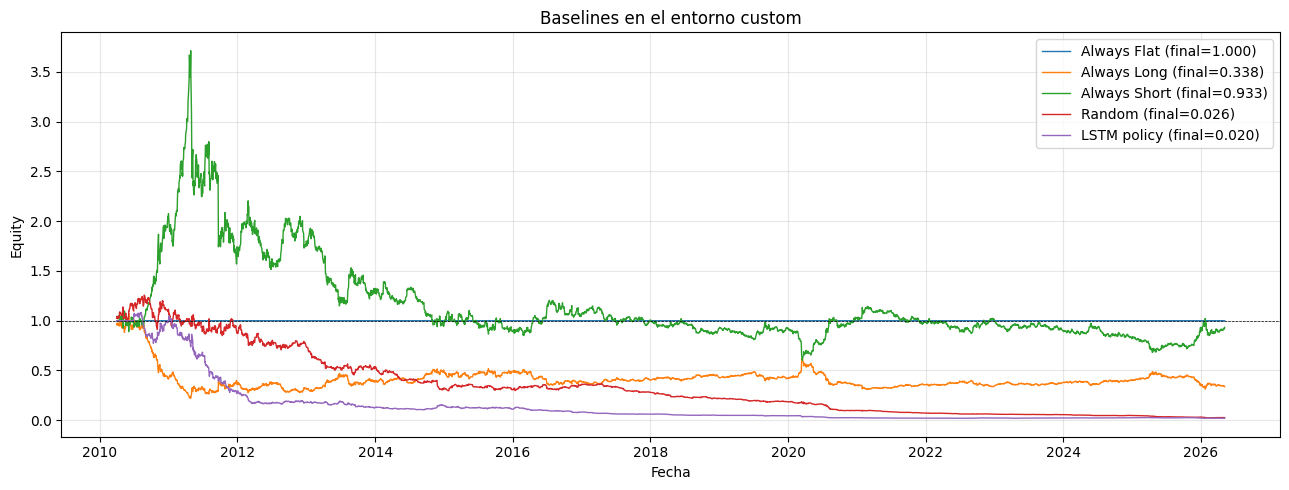

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for name in ['Always Flat', 'Always Long', 'Always Short', 'Random', 'LSTM policy']:
    p, eq, _ = run_policy({'Always Flat':pol_flat,'Always Long':pol_long,
                           'Always Short':pol_short,'Random':pol_random,
                           'LSTM policy':lstm_policy}[name], df)
    ax.plot(df.index[:len(eq)], eq, label=f'{name} (final={eq[-1]:.3f})', lw=1.0)
ax.axhline(1.0, color='black', ls='--', lw=0.5)
ax.set_title('Baselines en el entorno custom')
ax.set_ylabel('Equity'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(DATA_DIR / 'env_baselines.png', dpi=120)
plt.show()


## 7.5 Validacion: determinismo

In [6]:
# La env con mismas acciones debe dar mismos resultados
def fixed_policy_long(o,e): return 2
p1, eq1, _ = run_policy(fixed_policy_long, df, seed=0)
p2, eq2, _ = run_policy(fixed_policy_long, df, seed=0)
print(f'Determinismo OK: {np.allclose(eq1, eq2)}')
print(f'eq1[-1]={eq1[-1]:.6f}, eq2[-1]={eq2[-1]:.6f}')


Determinismo OK: True
eq1[-1]=0.337879, eq2[-1]=0.337879


## Conclusion Fase 7
- Entorno gym custom funcional, API correcta, deterministico.
- Baselines triviales (flat, long, short, random) ejecutan correctamente.
- Politica LSTM (umbral 0.55) ya consigue resultados razonables sin entrenamiento de RL.
- Listo para entrenar PPO en Fase 8.
